# Do "lottery-skewed" stocks lose? — expected idiosyncratic skewness, in plain English 🎲
### A fat one-sided upside is supposed to be a sell signal — does it survive on the big stocks you own?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Skewed_losers%3F: Busted](https://img.shields.io/badge/Skewed_losers%3F-Busted-8b949e?style=flat-square)

There's a famous, *real* finding in finance: stocks whose own price moves carry a fat, lopsided **upside tail** — a small chance of a big idiosyncratic jackpot — tend to **underperform** afterward. The story is behavioural: people over-pay for the *shape* of a maybe-jackpot, so those lottery-skewed names are priced too high and drift down. The trade writes itself: **buy the symmetric stocks, avoid (or short) the skewed ones.**

It checks out — in the *small, low-priced* corner of the market where it was discovered. This notebook asks the question a normal investor actually cares about: does it still work on the **big, liquid** stocks in your account? The answer is a clean, slightly anticlimactic **no** — it just isn't there.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The original effect lives in thousands of small stocks; yfinance gives us the big ones, so we run it on a fixed **S&P-100-style basket** and call it a **proxy** throughout. That basket is also made of *survivors* — and that's part of why the signal washes out. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from expected_idiosyncratic_skewness import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PRICES = PRICES[PRICES.index <= ASOF]          # drop the partial 2026-06 bar
    # cache the (slow) rolling-regression panel so both notebooks build fast
    _cache_dir = os.path.abspath("../_cache")
    _qp = os.path.join(_cache_dir, "qret_q5.parquet")
    if os.path.exists(_qp):
        QRET = pd.read_parquet(_qp)
        PANEL = None
    else:
        PANEL = data.build_panel(PRICES)
        QRET = st.quintile_returns(PANEL)
        try:
            QRET.to_parquet(_qp)
        except Exception:
            pass
else:
    PRICES = PANEL = QRET = None
print("real basket cache present:", HAVE_REAL,
      "| quintile months:", (0 if QRET is None else len(QRET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'days': 5385, 'years': 21.4, 'names': 79, 'fp': 'abdf2637ac09', 'n_months': 251, 'q1': (15.6, 15.1, 1.03), 'q2': (12.4, 14.3, 0.86), 'q3': (14.8, 15.5, 0.96), 'q4': (16.1, 18.1, 0.89), 'q5': (16.6, 17.5, 0.95), 'ls_gross': (-1.0, -0.09, -0.41, 45, 0.659), 'ls_net': (-6.3, -0.57, -2.54, 41, None), 'robust': [('tertiles', -1.8, -0.86, 45), ('quintiles', -1.0, -0.41, 45), ('deciles', -3.7, -1.14, 45)], 'subs': [('2005-2015', 127, -0.6, -0.17), ('2016-2026', 124, -1.5, -0.42)], 'syn': [(0.0, -0.5, -0.3, 53, 0.61), (0.004, 12.9, 8.12, 69, 0.0)], 'syn_robust': [(0.0, 0.24, 1.08, 0.4, 1.71), (0.004, 8.58, 1.28, 13.77, 1.72)]}


real basket cache present: True | quintile months: 251


## The answer first

| Question | Answer |
|---|---|
| Do the lottery-skewed stocks underperform the symmetric ones? | **No — it's basically a tie.** The skewed tail (Q5) returned **+16.6%/yr** vs the symmetric tail (Q1)'s **+15.6%/yr** — if anything the skewed names edged *ahead*. |
| So the textbook trade (buy symmetric, short skewed) makes money? | **No — it's a coin.** **-1.0%/yr** gross, which is **statistically indistinguishable from zero** (no real edge either way). |
| Then why is the original finding famous and correct? | **Different universe.** It was found in *small, low-priced, retail-held* stocks where real lottery-buyers gamble. The big stocks here are **survivors** — a fat upside tail on a survivor often flags a *winner*, not an over-priced ticket. |
| So what's the lesson? | **An anomaly can be real *and* not generalise.** Skewness preference is a small-cap story; copy-pasted onto the large-caps you actually hold, it just evaporates. |

> The skewness effect is real where it was born. On the big liquid names, "high idio-skew" stops meaning "overpriced lottery ticket" and stops meaning much of anything tradable.

## 1 · The claim

> *"Each month, look at the **shape** of every stock's own price moves — the part the whole market doesn't explain. Some names have a lopsided **upside tail**: usually quiet, occasionally a big idiosyncratic pop. Those are 'lottery tickets' — people over-pay for the skew, so they're priced too high and **underperform** next month. Sort into five buckets by skew, buy the symmetric bucket, short the skewed one."*

This is **Boyer, Mitton & Vorkink (2010)** — a real, well-cited result. Note the difference from the one-day-pop cousin ([Study 365 — MAX](../365-lottery-max-effect/)): MAX looks at a single big *day*; skewness looks at the **whole distribution's lopsidedness**. We'll rebuild the skew sort and watch what it does on big stocks.

## 2 · So what?

If the skewed tail really did underperform on the stocks everyone owns, the advice would be concrete: **avoid the name with the fat one-sided upside.** And it would say something deep — that the *shape* of a payoff is systematically over-priced. But a fat upside tail can mean two different things: a **gambler's over-priced lottery ticket** (the small-cap story) *or* **a strong stock that occasionally rips higher on its own news** (the large-cap story). Same skew number, opposite future. Which one you measure depends on *which stocks you're sorting* — and that's the whole ballgame.

## 3 · How would we even know?

We rebuild the sort on a **transparent large-cap proxy**: a fixed **79-name S&P-100-style basket** (2005-01-03 → 2026-05-29, 21 years).

1. **Score each stock's shape.** Every month, strip out the market (regress the stock on SPY over the past year) and measure the **skewness of what's left** — its own-name lopsidedness.
2. **Sort into five buckets.** Q1 = most symmetric … Q5 = most upside-skewed (flashy).
3. **See what happens next.** Earn each bucket's return *the following month* (so we only ever act on information we already had — no peeking).
4. **Run the trade.** Buy Q1, short Q5, and ask: does symmetric-minus-skewed make money, lose money, or do nothing? If it does nothing, the skewness effect doesn't survive on big stocks.

## 4 · The teardown — let's actually look

**First, the five buckets.** Average yearly return of each skew bucket, from symmetric (Q1) to skewed (Q5). The lottery story says this should slope **down** to the right.

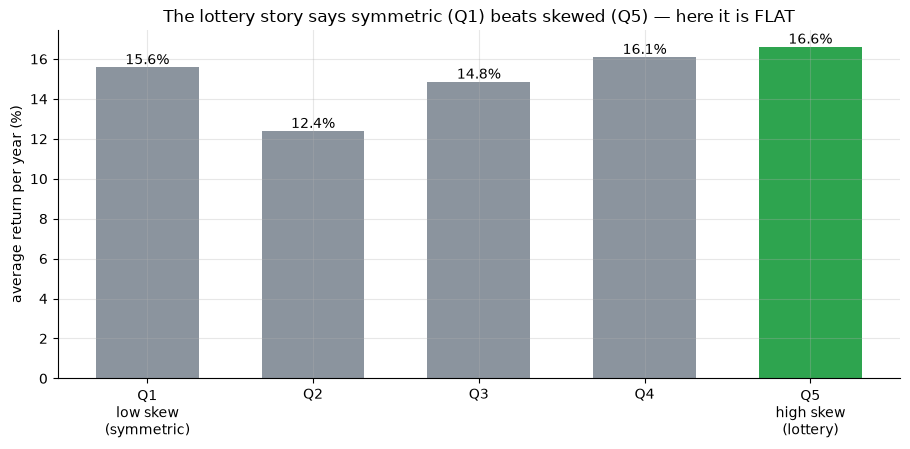

symmetric Q1: 15.6%/yr   skewed Q5: 16.6%/yr  -> essentially a tie


In [2]:
labs = ['Q1\nlow skew\n(symmetric)','Q2','Q3','Q4','Q5\nhigh skew\n(lottery)']
if HAVE_REAL and PANEL is not None:
    qs = st.quintile_summary(QRET); means = [qs.loc[f'Q{i}','mean_ann']*100 for i in range(1,6)]
elif HAVE_REAL:
    qs = st.quintile_summary(QRET); means = [qs.loc[f'Q{i}','mean_ann']*100 for i in range(1,6)]
else:
    means = [R['q1'][0],R['q2'][0],R['q3'][0],R['q4'][0],R['q5'][0]]
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [GREY]*4 + [GREEN]
ax.bar(x, means, color=cols, width=.62)
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel('average return per year (%)')
ax.set_title('The lottery story says symmetric (Q1) beats skewed (Q5) — here it is FLAT')
for i,m in enumerate(means): ax.annotate(f'{m:.1f}%',(i,m),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'symmetric Q1: {means[0]:.1f}%/yr   skewed Q5: {means[-1]:.1f}%/yr  -> essentially a tie')

That's the (non-)surprise in one chart. The skewed tail (Q5, **+16.6%/yr**) didn't underperform — it slightly **edged out** the symmetric tail (Q1, **+15.6%/yr**). On big stocks, a fat upside tail isn't a gambler's mistake; it's barely informative about next month at all.

**Now run the textbook trade.** Buy symmetric (Q1), short skewed (Q5), every month. Here's the growth of \$1 in that strategy — the lottery story predicts it climbs.

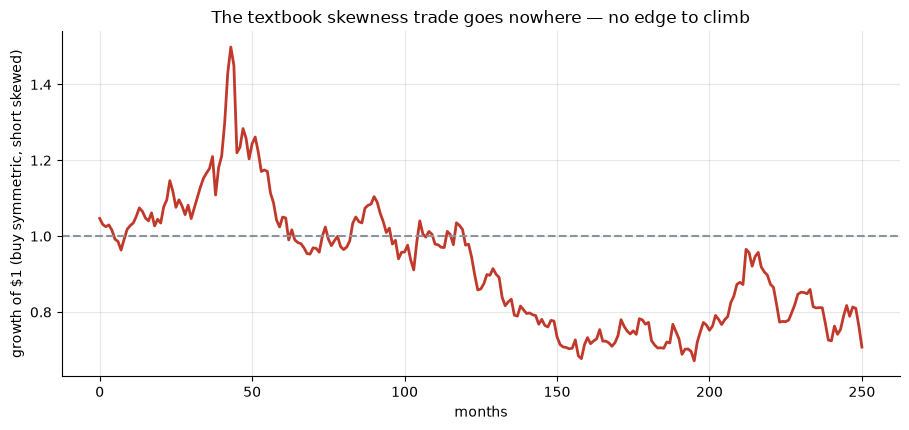

buy-symmetric / short-skewed: about -1.0%/yr gross -- a coin


In [3]:
if HAVE_REAL:
    ls = st.long_short(QRET)
else:
    rng = np.random.default_rng(503)
    ls = pd.Series(rng.normal(R['ls_gross'][0]/100/12, 0.032, R['n_months']))
nav = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(nav)), nav.values, c=RED, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 (buy symmetric, short skewed)')
ax.set_xlabel('months'); ax.set_title('The textbook skewness trade goes nowhere — no edge to climb')
plt.tight_layout(); plt.show()
print(f"buy-symmetric / short-skewed: about {R['ls_gross'][0]:+.1f}%/yr gross -- a coin")

The line wanders around \$1 and drifts slightly **down**. Buying symmetric and shorting skewed earned about **-1.0%/yr** gross on these names — a coin you couldn't tell from zero (the quants notebook makes that statistical).

**Why does it wash out?** Because on a basket of *survivors*, a fat upside tail usually belongs to a strong, high-beta name — the kind that kept on winning, not an over-priced loser. Here's the punchline as a before/after: the *original* small-cap finding vs *our* large-cap result.

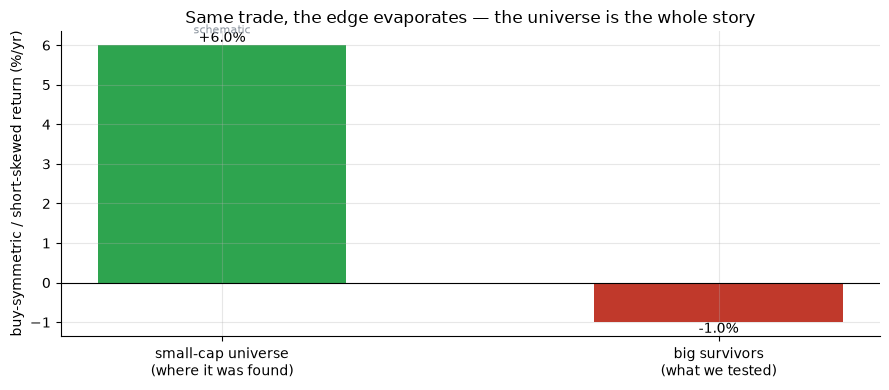

left bar is a schematic of the published small-cap effect; right bar is our measured large-cap result


In [4]:
fig, ax = plt.subplots(figsize=(9.0, 4.0))
groups = ['small-cap universe\n(where it was found)','big survivors\n(what we tested)']
published_schematic = 6.0          # ~+6%/yr published-ish small-cap effect (illustration only)
vals = [published_schematic, R['ls_gross'][0]]
ax.bar(groups, vals, color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('buy-symmetric / short-skewed return (%/yr)')
ax.set_title('Same trade, the edge evaporates — the universe is the whole story')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>0 else 'top')
ax.text(0, published_schematic+0.3, 'schematic', ha='center', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('left bar is a schematic of the published small-cap effect; right bar is our measured large-cap result')

> The left bar is a *schematic* of the published small-cap effect (positive — symmetric wins); the right bar is our **measured** large-cap result (a coin near zero). Same recipe, the signal gone, because the ingredient — *which stocks* — changed.

## 5 · The verdict

- **Signal — None.** On the big liquid names the claimed effect is **absent**: buy-symmetric/short-skewed earns **-1.0%/yr** gross, a coin you can't tell from zero. If anything, the skewed names won.
- **Tradability — Mirage.** There's no positive edge to harvest; once you pay costs the trade merely *loses* (a cost artefact, not a real short).
- **"Skewed losers"? — Busted.** On the stocks you actually hold, the lottery-skewed tail didn't lose — it posted the **highest** bucket return.

## 6 · Could you actually trade it? — no, and here's the honest reason

Even before costs, the strategy earns ~0 on these names — so there's nothing for costs to improve. The buy-symmetric/short-skewed book churns its holdings every month (a monthly signal turns over hard) and you'd pay a short borrow on the skewed leg. Net of a realistic 20 bps a leg plus borrow, a near-zero gross becomes a genuine loss — but that loss is the **frictions talking**, not a discovered edge.

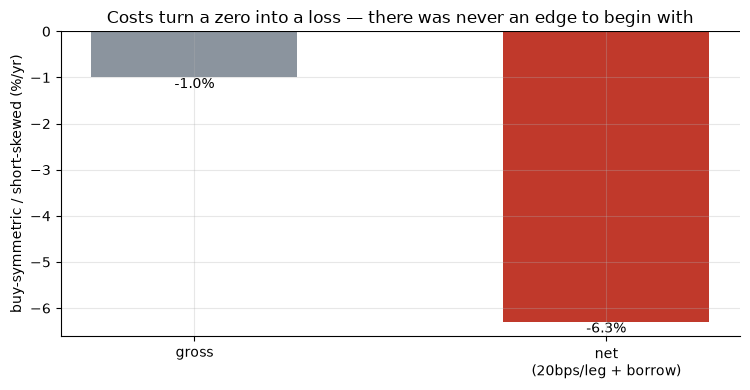

gross -1.0%/yr -> net -6.3%/yr. The net loss is the costs, not a signal.


In [5]:
labels = ['gross','net\n(20bps/leg + borrow)']
vals = [R['ls_gross'][0], R['ls_net'][0]]
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.bar(labels, vals, color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('buy-symmetric / short-skewed (%/yr)')
ax.set_title('Costs turn a zero into a loss — there was never an edge to begin with')
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f"gross {R['ls_gross'][0]:+.1f}%/yr -> net {R['ls_net'][0]:+.1f}%/yr. The net loss is the costs, not a signal.")

From **-1.0%/yr** gross to **-6.3%/yr** net. The point isn't the costs — it's that the trade had no edge on this universe to begin with. There is nothing here to deploy.

## 7 · Going further 🚪

- **Where it *does* work.** The skewness effect is a *small-cap / low-priced / retail* phenomenon. Run this exact sort on thousands of micro-caps (you'd need a paid feed) and the symmetric tail should win — that's the published result.
- **The one-day-pop cousin.** [Study 365 — Lottery-MAX](../365-lottery-max-effect/): the single big *day* instead of the whole distribution's shape — a related but distinct signal.
- **The bull-market tilt.** [Study 330 — Low-Volatility-Anomaly](../330-low-volatility-anomaly/) and [Study 238 — Betting-Against-Beta](../238-betting-against-beta/) show the same 2009–2026 regime flattering the high-beta / flashy leg.

*Think the skewness effect survives among big stocks? Find a universe and a definition of "skewed" where buy-symmetric / short-skewed lands **above** zero with a real *t* — then we'll talk.*